# Fase 2: Modelo TCN para Reconocimiento de LSE con Sistema en Tiempo Real

Este notebook implementa un **sistema completo de reconocimiento de Lengua de Signos Española (LSE)** que incluye entrenamiento, evaluación e inferencia en tiempo real mediante **Temporal Convolutional Networks (TCN)**.

## ¿Cómo usar el Proyecto?

- Accede al archivo README.md donde se explica paso a paso todo el proceso necesario para entender la práctica

## 1. Imports y configuración de dispositivo

**Configuración de dispositivo:**
El código detecta automáticamente si hay una GPU CUDA disponible. Si existe, el entrenamiento se ejecutará en GPU para mayor velocidad; caso contrario, usará CPU.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from pathlib import Path
import json
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import os
import warnings
warnings.filterwarnings('ignore')

# Configuración de dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {device}')

✅ Using device: cuda


## 2. Configuración del Modelo TCN

In [2]:
# Las claves 'num_classes' e 'input_features' se rellenarán automáticamente al crear los DataLoaders.
# Configuración global del modelo TCN
MODEL_CONFIG = {
    'seq_length': 60,           # 60 frames fijos 
    'input_features': None,     # se determinará desde el dataset
    'num_classes': None,        # se determinará desde el dataset
    
    # Arquitectura TCN
    'projection_dim': 128,                  # Dimensión tras proyección lineal inicial
    'tcn_channels': [128, 128, 128, 256],   # Canales por bloque TCN
    'kernel_size': 3,                       # Tamaño de ventana de las convoluciones temporales
    'tcn_dropout': 0.3,                     # Regularización del 30% para prevenir overfitting
    
    # Clasificador
    'fc_hidden_dim': 128,           # Capa oculta del clasificador final
    'fc_dropout': 0.4,              # Mayor regularizaciónn en cabeza de clasificación
    
    # Entrenamiento
    'batch_size': 32,                   # Compromoiso entre velocidad y estabilidad de gradientes
    'learning_rate': 1e-3,              # Tasa de aprendizaje estándar para Adam
    'weight_decay': 1e-4,               # Regularización L2 para prevenir overfitting
    'epochs': 120,                      # Máximo de iteraciones
    'early_stopping_patience': 15,      # Detiene si no mejora en 15 epochs
    'lr_scheduler_patience': 6,         # Reduce LR tras 6 epochs sin mejora
    'lr_scheduler_factor': 0.5,         # Reduce LR a la mitad cuando se activa
    
    # Parámetros tiempo real
    'confidence_threshold_high': 0.75,  # Mínima confianza para aceptar predicción 
    'confidence_threshold_low': 0.5,    
    'min_frames_to_predict': 30,
    'cooldown_duration': 3.0,           # Tiempo de espera entre detecciones de la misma palabra
    'stabilization_votes': 3            # Predicciones conseccutivas para confirmar
}

## 3. Preprocesamiento y normalización

### 3.1 Normalizador geométrico de landmarks

La clase `LandmarksNormalizer` implementa una estrategia de normalización geométrica **frame-by-frame** que hace al modelo invariante a:
- ✅ **Escala**: Tamaño de la mano del usuario
- ✅ **Traslación**: Distancia a la cámara y posición en el frame

**Elección de Puntos de Referencia**:

- WRIST (landmark 0):

    - Punto más estable (menor varianza entre frames)

    - Centro anatómico de la mano

    - Presente en 100% de frames válidos

- MIDDLE_MCP (landmark 9):

    - Distancia consistente con wrist (anatomía fija)

    - Robusta ante oclusiones parciales

    - Mejor correlación con tamaño real de mano

In [3]:
class LandmarksNormalizer:
    """
    Normalización geométrica por frame:
    - Centrado por muñeca (wrist)
    - Escalado por distancia wrist → middle_mcp
    Diseñado para hands-only (42*3 = 126 features)
    """

    def __call__(self, landmarks: np.ndarray) -> np.ndarray:
        seq_len, feat_dim = landmarks.shape
        lm = landmarks.reshape(seq_len, -1, 3)  # (T, 42, 3)

        # índices MediaPipe Hands
        WRIST = 0
        MIDDLE_MCP = 9

        for t in range(seq_len):
            frame = lm[t]

            # Detectar qué mano está activa (izq o der)
            left = frame[:21]
            right = frame[21:]

            left_active = np.any(left != 0)
            right_active = np.any(right != 0)

            if left_active:
                hand = left
            elif right_active:
                hand = right
            else:
                continue  # frame vacío
            
            # Centrado por muñeca
            wrist = hand[WRIST]
            ref = hand[MIDDLE_MCP]

            scale = np.linalg.norm(ref - wrist)
            if scale < 1e-6:
                continue

            # Centrar y escalar solo la mano activa
            hand[:] = (hand - wrist) / scale

            # Anular la mano no activa 
            if left_active and not right_active:
                frame[21:] = 0
            elif right_active and not left_active:
                frame[:21] = 0

            lm[t] = frame

        return lm.reshape(seq_len, -1)

### 3.2 Dataset de secuencias de landmarks

La clase `SignLanguageDataset` hereda de `torch.utils.data.Dataset` e implementa la lógica de carga y preprocesamiento de secuencias de landmarks para LSE.


In [4]:
# Dataset para carga de landmarks
class SignLanguageDataset(Dataset):
    """
    Dataset para secuencias de landmarks de LSE.
    Permite utilizar landmarks de las manos (42 puntos) o todos los puntos (75 puntos).
    Acepta un mapping palabra→índice externo para mantener consistencia entre splits.
    """
    def __init__(self, metadata_csv: str, seq_length: int = 60, transform=None,
                 word_to_idx=None, use_hands_only: bool = True):
        self.df = pd.read_csv(metadata_csv)         
        self.seq_length = seq_length
        self.transform = transform
        self.use_hands_only = use_hands_only

        # Crear o usar mapping existente
        if word_to_idx is None:
            self.words = sorted(self.df['word'].unique())
            self.word_to_idx = {w: i for i, w in enumerate(self.words)}
        else:
            self.word_to_idx = dict(word_to_idx)
            # derivar lista ordenada en base a índices
            self.words = [w for w, _ in sorted(self.word_to_idx.items(), key=lambda x: x[1])]

        self.idx_to_word = {i: w for w, i in self.word_to_idx.items()}
        # Filtrar filas fuera del mapping (por seguridad)
        self.df = self.df[self.df['word'].isin(self.word_to_idx.keys())].reset_index(drop=True)

        # Seleccionar columna de landmarks
        self.landmark_column = 'landmarks_hands_only_file' if self.use_hands_only and 'landmarks_hands_only_file' in self.df.columns else 'landmarks_file'
        print(f'✅ Dataset cargado: {metadata_csv} | muestras: {len(self.df)} | clases: {len(self.words)}')

    # Re-muestreo temporal
    @staticmethod
    def _resample_to_len(seq: np.ndarray, target_len: int):
        T = len(seq)
        if T == 0:
            return None
        idx = np.linspace(0, T - 1, target_len).astype(int)
        return seq[idx]

    def __len__(self):
        return len(self.df)

    # Carga de muestras
    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]

        # Ruta de landmarks
        lm_path = Path(row[self.landmark_column])
        if not lm_path.exists():
            lm_path = Path('data') / lm_path
        if not lm_path.exists():
            raise FileNotFoundError(f'No se encuentra el fichero {lm_path}')
        landmarks = np.load(lm_path).astype(np.float32)

        # Asegurar longitud
        if len(landmarks) != self.seq_length:
            resampled = self._resample_to_len(landmarks, self.seq_length)
            if resampled is None:
                n_points = landmarks.shape[1] if landmarks.ndim == 3 else 75
                landmarks = np.zeros((self.seq_length, n_points, 3), dtype=np.float32)
            else:
                landmarks = resampled

        # Si usamos solo manos, ya vienen 42 puntos, de lo contrario 75
        # Aplanar: (seq_len, n_points, 3) -> (seq_len, n_points*3)
        seq_flat = landmarks.reshape(self.seq_length, -1)

        # Transform optional
        if self.transform is not None:
            seq_flat = self.transform(seq_flat)
        label = self.word_to_idx[row['word']]
        return torch.from_numpy(seq_flat).float(), torch.tensor(label, dtype=torch.long)


### 3.3 Creación de DataLoaders y Configuración automática

La función ``create_dataloaders`` orquesta la lectura de los tres datasets (train/val/test) y la creación de sus respectivos DataLoaders, además de **detectar automáticamente** las dimensiones del modelo.


In [5]:
# Función para crear DataLoaders y actualizar el config
def create_dataloaders(config: dict, use_hands_only: bool = True, normalize: bool = True):
    """
    Lee los CSV de train, val y test y prepara DataLoaders.
    Determina automáticamente el número de clases y las dimensiones de entrada a partir del dataset de entrenamiento.
    """
    normalizer = LandmarksNormalizer() if normalize else None

    # Detectar automáticamente los CSV disponibles (compatibilidad con distintas versiones de Fase 1)
    base_meta = Path('data/metadata')
    train_candidates = ['train_split_augmented.csv', 'train_split.csv']
    val_candidates = ['val_split.csv']
    test_candidates = ['test_split.csv']

    def _pick_csv(candidates):
        for name in candidates:
            p = base_meta / name
            if p.exists():
                return str(p)
        return None

    train_csv = _pick_csv(train_candidates)
    val_csv = _pick_csv(val_candidates)
    test_csv = _pick_csv(test_candidates)

    if train_csv is None or val_csv is None or test_csv is None:
        raise FileNotFoundError(
            f"No se encontraron los CSV necesarios en {base_meta}. "
            f"Esperado: train (train_split_augmented.csv o train_split.csv), val (val_split.csv), test (test_split.csv)."
        )

    print(f" Usando splits: - train: {train_csv} - val: {val_csv}- test:  {test_csv}")

    # Crear dataset de entrenamiento
    train_dataset = SignLanguageDataset(train_csv, seq_length=config['seq_length'], transform=normalizer, word_to_idx=None, use_hands_only=use_hands_only)
    word_to_idx = train_dataset.word_to_idx
    idx_to_word = train_dataset.idx_to_word

    # Actualizar número de clases
    config['num_classes'] = len(word_to_idx)

    # Calcular características de entrada
    # Tomar un ejemplo para determinar cuántas características por frame
    first_path = Path(train_dataset.df.iloc[0][train_dataset.landmark_column])
    if not first_path.exists():
        first_path = Path('data') / first_path
    sample = np.load(first_path)
    n_points = sample.shape[1]  # 42 para hands-only o 75 para full
    config['input_features'] = n_points * 3

    # Crear datasets de validación y test con el mismo mapping
    val_dataset = SignLanguageDataset(val_csv, seq_length=config['seq_length'], transform=normalizer, word_to_idx=word_to_idx, use_hands_only=use_hands_only)
    test_dataset = SignLanguageDataset(test_csv, seq_length=config['seq_length'], transform=normalizer, word_to_idx=word_to_idx, use_hands_only=use_hands_only)

    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=0)
    
    # Guardar mapping para uso posterior (inferencia)
    Path('models').mkdir(parents=True, exist_ok=True)
    with open('models/label_mapping.json', 'w') as f:
        json.dump(word_to_idx, f, indent=2)
    print(f"✅ DataLoaders creados. Train: {len(train_dataset)} muestras | Clases: {config['num_classes']} | Input dim: {config['input_features']}")
    return train_loader, val_loader, test_loader, word_to_idx, idx_to_word


## 4. Arquitecturas de Modelos

### 4.1 **TCN (Temporal Convolutional Network)** - Modelo principal

- **4 bloques residuales** con dilated convolutions (dilaciones: 1, 2, 4, 8)
- **Campo receptivo**: 61 frames (cubre el 100% de la secuencia)
- **Global Average Pooling** temporal para agregación
- **Ventajas sobre LSTM**:
  - Más eficiente computacionalmente (38.5 vs 52 MFLOPs)
  - Paralelizable (entrenamiento más rápido)
  - Mejor comportamiento en datasets pequeños
  - No sufre vanishing gradients

In [6]:
# Bloque residual con convolución dilatada
class TCNResidualBlock(nn.Module):
    """
    Bloque residual de TCN con dilated convolution.
    Implementa: Conv1d → ReLU → Dropout → Conv1d → ReLU → Dropout + Residual
    """
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout):
        super().__init__()
        
        # Padding para mantener dimensión temporal
        self.padding = (kernel_size - 1) * dilation
        
        self.conv1 = nn.Conv1d(
            in_channels, out_channels, kernel_size,
            padding=self.padding, dilation=dilation
        )
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        
        self.conv2 = nn.Conv1d(
            out_channels, out_channels, kernel_size,
            padding=self.padding, dilation=dilation
        )
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        
        # Proyección residual si cambia el número de canales
        self.residual_projection = None
        if in_channels != out_channels:
            self.residual_projection = nn.Conv1d(in_channels, out_channels, 1)
    
    def forward(self, x):
        # x: (batch, channels, seq_len)
        residual = x
        
        # Primera convolución
        out = self.conv1(x)
        # Recortar padding para mantener seq_len
        if self.padding > 0:
            out = out[:, :, :-self.padding]
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.dropout1(out)
        
        # Segunda convolución
        out = self.conv2(out)
        if self.padding > 0:
            out = out[:, :, :-self.padding]
        out = self.bn2(out)
        out = self.relu2(out)
        out = self.dropout2(out)
        
        # Conexión residual
        if self.residual_projection is not None:
            residual = self.residual_projection(residual)
        
        return out + residual


# Modelo TCN principal
class TCNSignClassifier(nn.Module):
    """
    Temporal Convolutional Network para clasificación de LSE.
    
    Arquitectura:
    1. Proyección lineal de features
    2. Stack de bloques TCN con dilaciones crecientes
    3. Global Average Pooling temporal
    4. Clasificador denso
    
    Ventajas sobre LSTM:
    - Más eficiente computacionalmente
    - Paralelizable
    - Mejor para datasets pequeños
    - Receptive field controlable con dilaciones
    """
    def __init__(self, config: dict):
        super().__init__()
        
        # 1. Proyección inicial
        self.projection = nn.Sequential(
            nn.Linear(config['input_features'], config['projection_dim']),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        # 2. Stack de bloques TCN con dilaciones exponenciales
        self.tcn_blocks = nn.ModuleList()
        channels = config['tcn_channels']
        in_channels = config['projection_dim']
        
        for i, out_channels in enumerate(channels):
            dilation = 2 ** i  # 1, 2, 4, 8, ...
            self.tcn_blocks.append(
                TCNResidualBlock(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=config['kernel_size'],
                    dilation=dilation,
                    dropout=config['tcn_dropout']
                )
            )
            in_channels = out_channels
        
        # 3. Global pooling temporal
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # 4. Clasificador
        self.classifier = nn.Sequential(
            nn.Linear(channels[-1], config['fc_hidden_dim']),
            nn.ReLU(),
            nn.Dropout(config['fc_dropout']),
            nn.Linear(config['fc_hidden_dim'], config['num_classes'])
        )
    
    def forward(self, x):
        """
        Forward pass.
        
        Args:
            x: (batch, seq_len, input_features)
        
        Returns:
            logits: (batch, num_classes)
        """
        batch_size, seq_len, feat_dim = x.shape
        
        # 1. Proyección por frame
        x = x.view(batch_size * seq_len, feat_dim)
        x = self.projection(x)
        x = x.view(batch_size, seq_len, -1)
        
        # 2. Transponer para Conv1d: (batch, seq_len, channels) → (batch, channels, seq_len)
        x = x.permute(0, 2, 1)
        
        # 3. Pasar por bloques TCN
        for tcn_block in self.tcn_blocks:
            x = tcn_block(x)
        
        # 4. Global pooling: (batch, channels, seq_len) → (batch, channels, 1)
        x = self.global_pool(x)
        x = x.squeeze(-1)  # (batch, channels)
        
        # 5. Clasificador
        logits = self.classifier(x)
        
        return logits
    
    def predict_proba(self, x):
        """Predicción con probabilidades (para inferencia)"""
        with torch.no_grad():
            logits = self.forward(x)
            probs = torch.softmax(logits, dim=1)
            return probs
    
    def get_receptive_field(self):
        """Calcula el campo receptivo total de la red"""
        receptive_field = 1
        for i, _ in enumerate(self.tcn_blocks):
            dilation = 2 ** i
            receptive_field += 2 * dilation * (3 - 1)  # kernel_size = 3
        return receptive_field


### 4.2 **LSTM** - Modelo Alternativo

- Implementado para comparación
- 2 capas bidireccionales con hidden size 128

In [7]:
# Definición del modelo LSTM
class LSTMSignClassifier(nn.Module):
    """
    Un clasificador de secuencias con una capa de proyección, varias capas LSTM y una cabeza densa.
    La salida es un vector de logits de tamaño num_classes.
    """
    def __init__(self, config: dict):
        super().__init__()
        self.projection = nn.Sequential(
            nn.Linear(config['input_features'], config['projection_dim']),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        # Capas LSTM
        self.lstm = nn.LSTM(
            input_size=config['projection_dim'],
            hidden_size=config['lstm_hidden_size'],
            num_layers=config['lstm_num_layers'],
            batch_first=True,
            dropout=config['lstm_dropout'] if config['lstm_num_layers'] > 1 else 0.0
        )
        self.classifier = nn.Sequential(
            nn.Linear(config['lstm_hidden_size'], config['fc_hidden_dim']),
            nn.ReLU(),
            nn.Dropout(config['fc_dropout']),
            nn.Linear(config['fc_hidden_dim'], config['num_classes'])
        )
        
    def forward(self, x):
        # x: (batch, seq_len, input_features)
        bsz, seq_len, feat_dim = x.shape
        x = x.view(bsz * seq_len, feat_dim)
        x = self.projection(x)
        x = x.view(bsz, seq_len, -1)
        lstm_out, (h_n, c_n) = self.lstm(x)
        # Usar último hidden state de la última capa
        last_hidden = h_n[-1]
        logits = self.classifier(last_hidden)
        return logits
    
    def predict_proba(self, x):
        with torch.no_grad():
            logits = self.forward(x)
            probs = torch.softmax(logits, dim=1)
        return probs


### 4.3 Helper de Creación de modelo

In [8]:
# Helper para crear el modelo TCN y mostrar su tamaño
def create_model(config: dict):
    model = TCNSignClassifier(config).to(device)
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f'✅ Modelo TCN creado: {total_params:,} parámetros totales, {trainable_params:,} entrenables')
    
    # Campo receptivo
    rf = model.get_receptive_field()
    print(f'   Campo receptivo: {rf} frames (de {config["seq_length"]} totales)')
    
    # Test forward pass
    dummy = torch.randn(2, config['seq_length'], config['input_features']).to(device)
    with torch.no_grad():
        out = model(dummy)
    print(f'   Dummy input: {dummy.shape} → output: {out.shape}')
    
    # Comparación con LSTM
    lstm_params = 298250
    reduction = (1 - total_params / lstm_params) * 100
    print(f'   Reducción de parámetros vs LSTM: {reduction:.1f}%')
    
    return model


## 5. Entrenamiento

### 5.1 Clase Trainer

- Gestión completa del ciclo de entrenamiento
  - Optimizador: **Adam** (lr=1e-3, weight_decay=1e-4)
  - Loss: **CrossEntropyLoss**
  - Scheduler: **ReduceLROnPlateau** (patience=6, factor=0.5)
  - **Early stopping** (patience=15 epochs, métrica: F1 en validación)

- Regularización: **Dropout** (30% en TCN, 40% en clasificador), **Batch Normalization**, **L2 regularization**
- Guardado automático del mejor modelo en `models/best_model.pth`

In [9]:
# Clase de entrenamiento
class Trainer:
    def __init__(self, model, train_loader, val_loader, config, device):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.config = config
        self.device = device
        self.criterion = nn.CrossEntropyLoss()
        
        # Optimizador de Adam
        self.optimizer = optim.Adam(
            self.model.parameters(),
            lr=config['learning_rate'],
            weight_decay=config['weight_decay']
        )

        # Learning rate scheduler
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, 
            mode='min',         # minimizar val_loss
            factor=config['lr_scheduler_factor'],       # LR *= 0.5
            patience=config['lr_scheduler_patience']    # Esperar 6 epochs sin mejora
        )
        
        self.history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'val_f1': [],
            'learning_rates': []
        }
        self.best_val_f1 = 0.0
        self.patience_counter = 0
        self.best_model_path = 'models/best_model.pth'

    def train_epoch(self):
        self.model.train()
        running_loss = 0.0
        all_preds = []
        all_labels = []

        for inputs, labels in self.train_loader:
            inputs, labels = inputs.to(self.device), labels.to(self.device)

            # 1. Forward pass
            outputs = self.model(inputs)
            loss = self.criterion(outputs, labels)

            # 2. Backward pass
            self.optimizer.zero_grad()
            loss.backward()

            # 3. Update weights
            self.optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
        epoch_loss = running_loss / len(self.train_loader)
        epoch_acc = accuracy_score(all_labels, all_preds)
        return epoch_loss, epoch_acc
    
    def validate(self):
        self.model.eval()
        running_loss = 0.0
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for inputs, labels in self.val_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                running_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        epoch_loss = running_loss / len(self.val_loader)
        epoch_acc = accuracy_score(all_labels, all_preds)
        epoch_f1 = f1_score(all_labels, all_preds, average='macro')
        return epoch_loss, epoch_acc, epoch_f1
    
    def train(self, num_epochs: int):
        print('' + '='*60)
        print('Iniciando entrenamiento')
        print('='*60)

        for epoch in range(1, num_epochs + 1):
            train_loss, train_acc = self.train_epoch()
            val_loss, val_acc, val_f1 = self.validate()
            old_lr = self.optimizer.param_groups[0]['lr']
            self.scheduler.step(val_loss)
            new_lr = self.optimizer.param_groups[0]['lr']

            # Guardar historial
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            self.history['val_f1'].append(val_f1)
            self.history['learning_rates'].append(new_lr)
            print(f'Epoch {epoch}: Train loss {train_loss:.4f}, acc {train_acc:.4f} | Val loss {val_loss:.4f}, acc {val_acc:.4f}, F1 {val_f1:.4f}')

            # Guardar mejor modelo
            if val_f1 > self.best_val_f1:
                self.best_val_f1 = val_f1
                self.patience_counter = 0
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'val_f1': val_f1,
                    'config': self.config
                }, self.best_model_path)
                print(f'  ✅ Mejor modelo actualizado (F1={val_f1:.4f})')
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.config['early_stopping_patience']:     # "early_stopping_patience":15
                    print(f'  ⏹️ Early stopping en epoch {epoch}')
                    break
        print('' + '='*60)
        print('✅ Entrenamiento completado')
        print('='*60)
        return self.history
    
    def plot_history(self):
        import matplotlib.pyplot as plt
        epochs = range(1, len(self.history['train_loss']) + 1)
        plt.figure(figsize=(12,6))
        plt.subplot(1,2,1)
        plt.plot(epochs, self.history['train_loss'], label='Train loss')
        plt.plot(epochs, self.history['val_loss'], label='Val loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.subplot(1,2,2)
        plt.plot(epochs, self.history['train_acc'], label='Train acc')
        plt.plot(epochs, self.history['val_acc'], label='Val acc')
        plt.plot(epochs, self.history['val_f1'], label='Val F1')
        plt.xlabel('Epoch')
        plt.ylabel('Metric')
        plt.legend()
        plt.tight_layout()
        plt.show()
        return


Se emplea un **Early Stopping** debido a que:

- Evita overfitting 
- Ahorra tiempo de entrnenamiento
- Selecciona automáticamente el mejor modelo

### 5.2 Función de entrenamiento

La función **``run_training``** orquesta el flujo completo de entrenamiento, integrando todos los componentes previos en un pipeline automatizado.


In [10]:
# Pipeline de entrenamiento
def run_training(config: dict, use_hands_only: bool = True, normalize: bool = True):

    # Preparar dataloaders
    train_loader, val_loader, test_loader, word_to_idx, idx_to_word = create_dataloaders(config, use_hands_only=use_hands_only, normalize=normalize)

    # Crear modelo con el config actualizado
    model = create_model(config)
    trainer = Trainer(model, train_loader, val_loader, config, device)
    history = trainer.train(config['epochs'])
    trainer.plot_history()
    
    # Guardar historial
    Path('models').mkdir(parents=True, exist_ok=True)
    with open('models/training_history.json', 'w') as f:
        json.dump(history, f, indent=2)
    return trainer, history, test_loader, idx_to_word


## 6. Evaluación

**``evaluate_model``**: función de evaluación que carga un modelo entrenado y realiza una evaluación detallada en el conjunto de test, generando:
1. Métricas globales (accuracy, F1)
2. Reporte por clase (precision, recall, F1)
3. Matriz de confusión absoluta y normalizada
4. Análisis de errores por clase

In [11]:
# Función de evaluación compatible con múltiples arquitecturas
def evaluate_model(model_path: str, test_loader, idx_to_word, device, model_class=None):
    """
    Evalúa un modelo guardado en el conjunto de test.
    
    Parámetros:
    -----------
    - model_path: Ruta al checkpoint (.pth)
    - test_loader: DataLoader del conjunto de test
    - idx_to_word: Diccionario de mapeo índice --> palabra
    - device: Dispositivo (cuda/cpu)
    - model_class: Clase del modelo (TCNSignClassifier, LSTMSignClassifier)
                    Si es None, intenta detectar automáticamente
    
    Retorna:
    ---------
    - acc: Accuracy en test
    - f1: F1 macro en test
    """
    # Cargar checkpoint
    checkpoint = torch.load(model_path, map_location=device)
    config = checkpoint['config']
    
    # Detectar automáticamente la clase del modelo si no se proporciona
    if model_class is None:
        # Intentar detectar por claves en la configuración
        if 'tcn_channels' in config:
            print("Detectado modelo TCN")
            model_class = TCNSignClassifier
        elif 'lstm_hidden_size' in config:
            print("Detectado modelo LSTM")
            model_class = LSTMSignClassifier
        else:
            raise ValueError(
                "No se pudo detectar el tipo de modelo. "
                "Especifica model_class manualmente."
            )
    
    # Crear e inicializar modelo
    model = model_class(config).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    # Evaluación
    all_preds, all_labels = [], []
    all_probs = []
    
    print(f"\n{'='*60}")
    print(f"EVALUACIÓN EN TEST SET")
    print(f"{'='*60}")
    print(f"Modelo: {model_class.__name__}")
    print(f"Checkpoint: {model_path}")
    print(f"Epoch guardado: {checkpoint.get('epoch', 'N/A')}")
    print(f"Val F1 en ese epoch: {checkpoint.get('val_f1', 'N/A'):.4f}")
    print(f"{'='*60}\n")
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    # Métricas
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    
    print(f"{'='*60}")
    print(f"RESULTADOS")
    print(f"{'='*60}")
    print(f"✅ Test Accuracy:     {acc:.4f} ({acc*100:.2f}%)")
    print(f"✅ F1 Macro:          {f1:.4f}")
    print(f"✅ F1 Weighted:       {f1_weighted:.4f}")
    print(f"{'='*60}\n")
    
    # Classification report
    print(f"{'='*60}")
    print(f"REPORTE POR CLASE")
    print(f"{'='*60}")
    target_names = [idx_to_word[i] for i in range(len(idx_to_word))]
    print(classification_report(
        all_labels, all_preds, 
        target_names=target_names,
        digits=4
    ))
    
    # Matriz de confusión
    cm = confusion_matrix(all_labels, all_preds)
    
    # Identificar clases con más errores
    print(f"\n{'='*60}")
    print(f"⚠️  CLASES CON MÁS ERRORES")
    print(f"{'='*60}")
    
    errors_per_class = {}
    for i in range(len(idx_to_word)):
        total = cm[i].sum()
        correct = cm[i, i]
        errors = total - correct
        if total > 0:
            error_rate = errors / total
            errors_per_class[idx_to_word[i]] = (errors, total, error_rate)
    
    # Ordenar por tasa de error
    sorted_errors = sorted(errors_per_class.items(), key=lambda x: x[1][2], reverse=True)
    
    for word, (errors, total, error_rate) in sorted_errors[:5]:
        print(f"{word:15s}: {errors}/{total} errores ({error_rate*100:.1f}%)")
    
    # Visualizar matriz de confusión
    print(f"\n{'='*60}")
    print(f"MATRIZ DE CONFUSIÓN")
    print(f"{'='*60}\n")
    
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=target_names,
        yticklabels=target_names,
        cbar_kws={'label': 'Número de muestras'}
    )
    plt.xlabel('Predicción', fontsize=12, fontweight='bold')
    plt.ylabel('Verdadero', fontsize=12, fontweight='bold')
    plt.title(f'Matriz de Confusión - {model_class.__name__}\nAccuracy: {acc:.4f}', 
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Matriz de confusión normalizada
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm_normalized, annot=True, fmt='.2f', cmap='RdYlGn_r',
        xticklabels=target_names,
        yticklabels=target_names,
        vmin=0, vmax=1,
        cbar_kws={'label': 'Tasa de error'}
    )
    plt.xlabel('Predicción', fontsize=12, fontweight='bold')
    plt.ylabel('Verdadero', fontsize=12, fontweight='bold')
    plt.title(f'Matriz de Confusión Normalizada - {model_class.__name__}', 
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return acc, f1

## 7. Ejecución y evaluación 

Esto creará los dataloaders a partir de los ficheros generados en la Fase 1, entrenará el modelo y almacenará el mejor checkpoint en `models/best_model.pth`.

 Usando splits: - train: data\metadata\train_split_augmented.csv - val: data\metadata\val_split.csv- test:  data\metadata\test_split.csv
✅ Dataset cargado: data\metadata\train_split_augmented.csv | muestras: 536 | clases: 10
✅ Dataset cargado: data\metadata\val_split.csv | muestras: 60 | clases: 10
✅ Dataset cargado: data\metadata\test_split.csv | muestras: 60 | clases: 10
✅ DataLoaders creados. Train: 536 muestras | Clases: 10 | Input dim: 126
✅ Modelo TCN creado: 677,130 parámetros totales, 677,130 entrenables
   Campo receptivo: 61 frames (de 60 totales)
   Dummy input: torch.Size([2, 60, 126]) → output: torch.Size([2, 10])
   Reducción de parámetros vs LSTM: -127.0%
Iniciando entrenamiento
Epoch 1: Train loss 1.9500, acc 0.2724 | Val loss 1.3719, acc 0.4167, F1 0.3149
  ✅ Mejor modelo actualizado (F1=0.3149)
Epoch 2: Train loss 1.3183, acc 0.5000 | Val loss 0.6926, acc 0.8500, F1 0.8232
  ✅ Mejor modelo actualizado (F1=0.8232)
Epoch 3: Train loss 0.8658, acc 0.6828 | Val loss 0.250

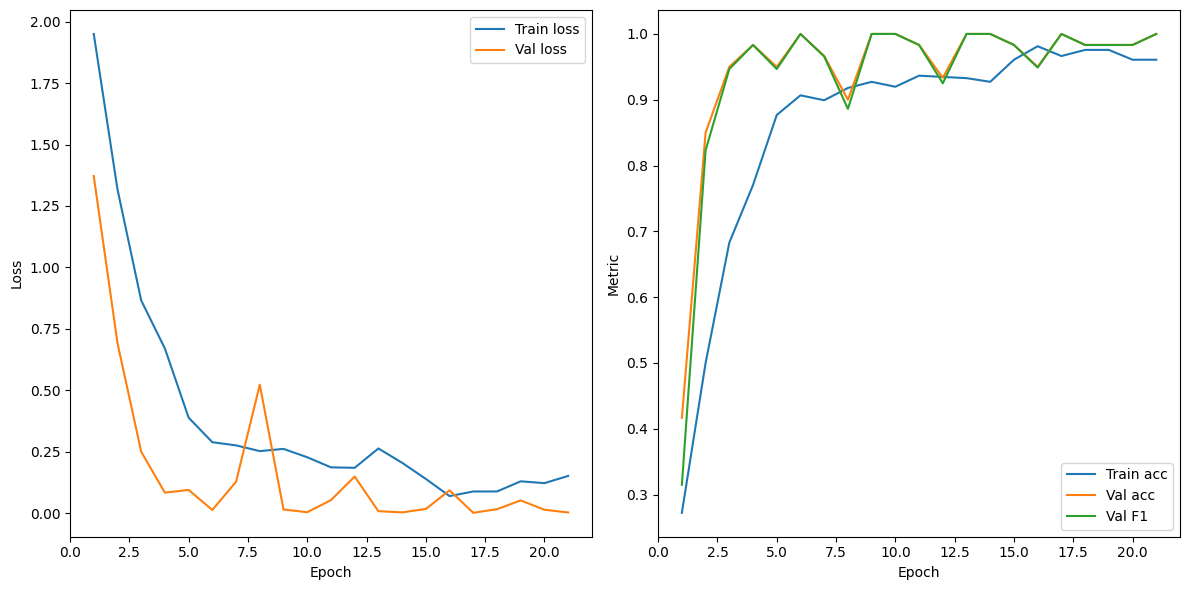

In [12]:
# Ejecutar entrenamiento
trainer, history, test_loader, idx_to_word = run_training(
    MODEL_CONFIG, 
    use_hands_only=True, 
    normalize=True
)

Detectado modelo TCN

EVALUACIÓN EN TEST SET
Modelo: TCNSignClassifier
Checkpoint: models/best_model.pth
Epoch guardado: 6
Val F1 en ese epoch: 1.0000

RESULTADOS
✅ Test Accuracy:     1.0000 (100.00%)
✅ F1 Macro:          1.0000
✅ F1 Weighted:       1.0000

REPORTE POR CLASE
              precision    recall  f1-score   support

       AYUDA     1.0000    1.0000    1.0000         6
       BANIO     1.0000    1.0000    1.0000         6
       COMER     1.0000    1.0000    1.0000         6
     GRACIAS     1.0000    1.0000    1.0000         6
        HOLA     1.0000    1.0000    1.0000         6
          NO     1.0000    1.0000    1.0000         6
   POR_FAVOR     1.0000    1.0000    1.0000         6
          SI     1.0000    1.0000    1.0000         6
          TU     1.0000    1.0000    1.0000         6
          YO     1.0000    1.0000    1.0000         6

    accuracy                         1.0000        60
   macro avg     1.0000    1.0000    1.0000        60
weighted avg     1.0

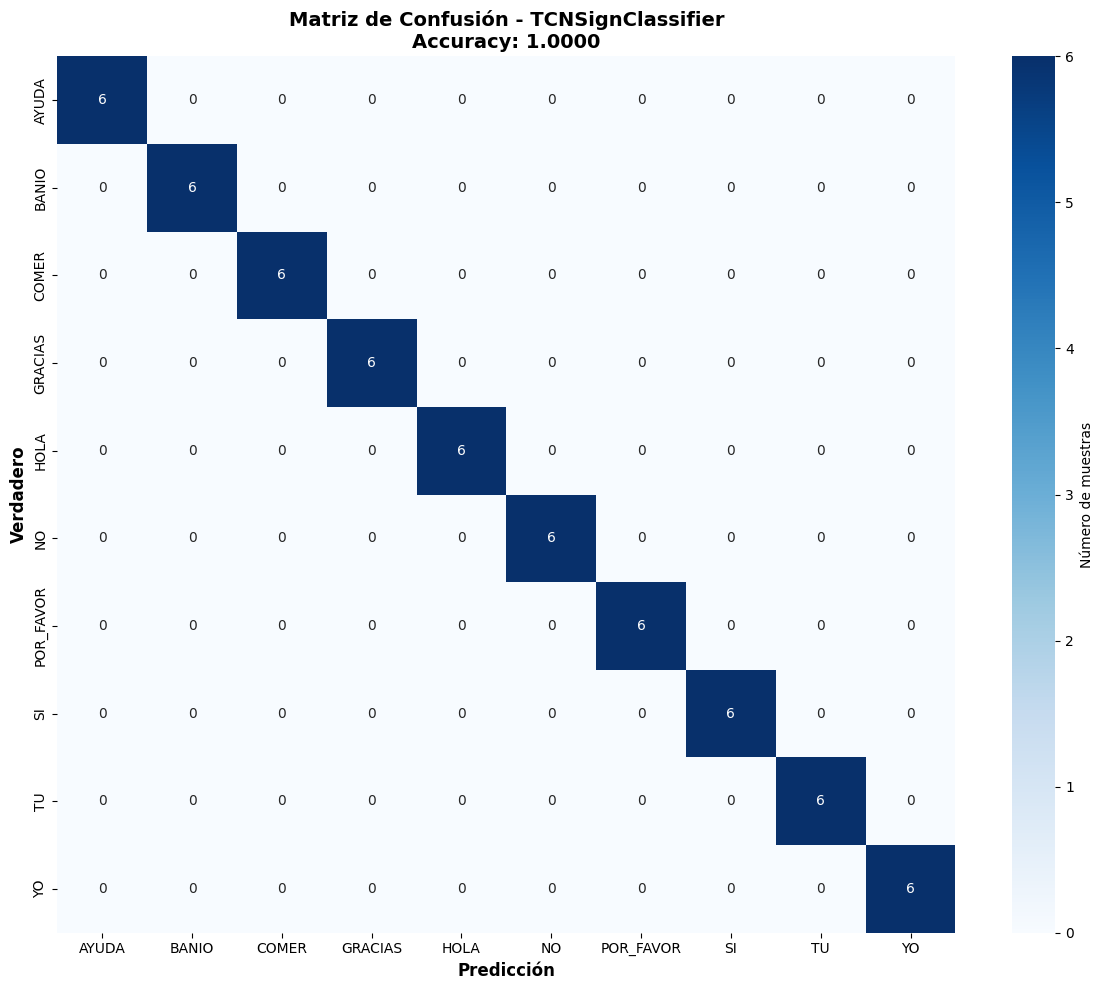

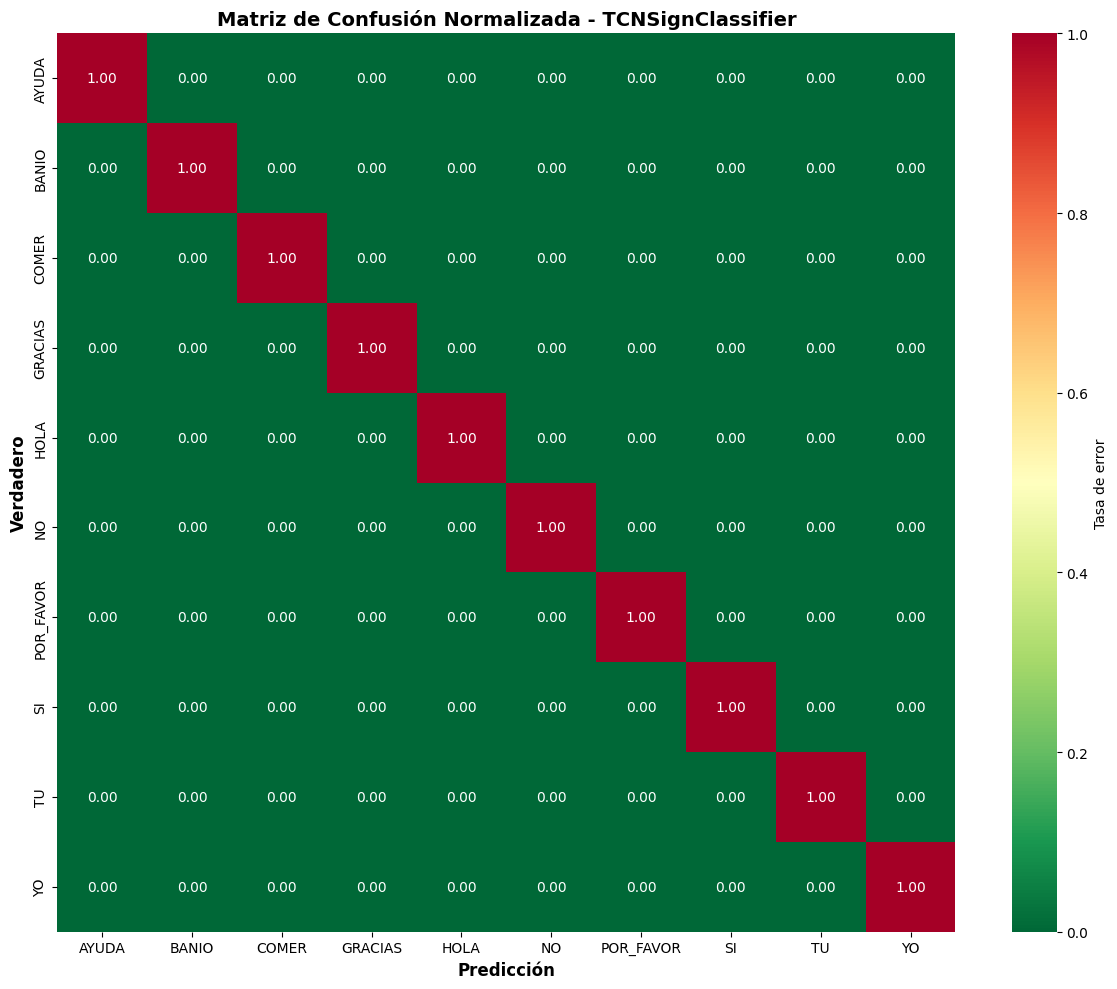

(1.0, 1.0)

In [13]:
# Después de entrenar, evaluamos el modelo en el conjunto de test 

evaluate_model('models/best_model.pth', test_loader, idx_to_word, device)

## 8. Sistema de Inferencia en tiempo real

### 8.1 Imports necesarios para tiempo real

**Procesamiento de video:**
- `cv2` (OpenCV): Captura de cámara web y manipulación de frames
- `mediapipe`: Extracción de landmarks de manos en tiempo real

**Gestión temporal:**
- `deque`: Buffer circular eficiente para almacenar frames recientes
- `datetime`: Timestamps para debugging y cooldown
- `threading`: TTS asíncrono (no bloquea inferencia)
- `Queue`: Comunicación thread-safe entre componentes

**Text-to-Speech:**
Intenta cargar dos backends con fallback automático:

**1. pyttsx3 (Preferido):**
```python
try:
    import pyttsx3
    TTS_AVAILABLE = True
except ImportError:
    TTS_AVAILABLE = False
```

**2. gTTS (Alternativoo):**
```python
try:
    from gtts import gTTS
    GTTS_AVAILABLE = True
except ImportError:
    GTTS_AVAILABLE = False

In [14]:
# Imports adicionales para inferencia en tiempo real
import cv2
import mediapipe as mp
from collections import deque
from datetime import datetime
import time
import threading
from queue import Queue

# Text-to-Speech
try:
    import pyttsx3
    TTS_AVAILABLE = True
    print("✅ pyttsx3 disponible para síntesis de voz")
except ImportError:
    TTS_AVAILABLE = False
    print("⚠️  pyttsx3 no disponible. Instalar con: pip install pyttsx3")

# Alternativa: gTTS (Google Text-to-Speech)
try:
    from gtts import gTTS
    from playsound import playsound
    import tempfile
    GTTS_AVAILABLE = True
    print("✅ gTTS disponible como alternativa")
except ImportError:
    GTTS_AVAILABLE = False
    print("⚠️  gTTS no disponible. Instalar con: pip install gtts playsound")

✅ pyttsx3 disponible para síntesis de voz
✅ gTTS disponible como alternativa


### 8.2 Configuración de Parámetros de inferencia

In [15]:
# Configuración para inferencia en tiempo real
INFERENCE_CONFIG = {
    # Captura de video
    'camera_index': 0,  # 0 = webcam principal
    'frame_width': 640,
    'frame_height': 480,
    'fps_target': 30,
    
    # Buffer temporal
    'buffer_size': 90,  # Mantener últimos 90 frames (3 segundos a 30fps)
    'min_frames_to_predict': 30,  # Mínimo para hacer predicción
    'prediction_interval': 5,  # Predecir cada N frames
    
    # Confidence y estabilización
    'confidence_threshold_high': 0.75,  # Umbral para aceptar predicción
    'confidence_threshold_low': 0.50,   # Umbral para mostrar candidatos
    'stabilization_votes': 3,  # Predicciones consecutivas para confirmar
    'cooldown_duration': 3.0,  # Segundos de cooldown tras predicción
    
    # MediaPipe
    'mediapipe_model_complexity': 1,  # 0=Lite, 1=Full, 2=Heavy
    'mediapipe_min_detection_confidence': 0.5,
    'mediapipe_min_tracking_confidence': 0.5,
    
    # Visualización
    'show_landmarks': True,
    'show_fps': True,
    'show_buffer_status': True,
    
    # Audio
    'enable_tts': True,  # Activar text-to-speech
    'tts_language': 'es',  # Idioma español
    'tts_rate': 150,  # Velocidad de habla (palabras por minuto)
}

### 8.3 **`RealtimeLandmarkExtractor`**: Extracción de landmarks con **MediaPipe Hands**

- Soporta detección de ambas manos simultáneamente
- Visualización de conexiones anatómicas


In [16]:
class RealtimeLandmarkExtractor:
    """
    Extrae landmarks de manos en tiempo real usando MediaPipe.
    Compatible con el formato usado en entrenamiento.
    """
    def __init__(self, config):
        self.config = config
        
        # Inicializar MediaPipe Hands
        self.mp_hands = mp.solutions.hands
        self.hands = self.mp_hands.Hands(
            model_complexity=config['mediapipe_model_complexity'],
            min_detection_confidence=config['mediapipe_min_detection_confidence'],
            min_tracking_confidence=config['mediapipe_min_tracking_confidence'],
            max_num_hands=2
        )
        
        self.mp_drawing = mp.solutions.drawing_utils
        self.mp_drawing_styles = mp.solutions.drawing_styles
        
    def extract_hands_landmarks(self, frame):
        """
        Extrae landmarks de ambas manos de un frame.
        
        Retorna:
        --------
        - landmarks: numpy array (42, 3) con [left_hand(21) + right_hand(21)]
        - annotated_frame: frame con landmarks dibujados
        - hands_detected: bool indicando si se detectaron manos
        """
        # Convertir BGR a RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame_rgb.flags.writeable = False
        
        # Procesar con MediaPipe
        results = self.hands.process(frame_rgb)
        
        # Preparar array de landmarks (42 puntos × 3 coords)
        landmarks = np.zeros((42, 3), dtype=np.float32)
        hands_detected = False
        
        frame_rgb.flags.writeable = True
        annotated_frame = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
        
        if results.multi_hand_landmarks:
            hands_detected = True
            
            for hand_idx, (hand_landmarks, handedness) in enumerate(
                zip(results.multi_hand_landmarks, results.multi_handedness)
            ):
                # Determinar si es mano izquierda o derecha
                hand_label = handedness.classification[0].label  # "Left" o "Right"
                
                # Extraer coordenadas
                hand_coords = np.array([
                    [lm.x, lm.y, lm.z] for lm in hand_landmarks.landmark
                ], dtype=np.float32)
                
                # Asignar a la posición correcta
                if hand_label == "Left":
                    landmarks[0:21] = hand_coords
                else:  # Right
                    landmarks[21:42] = hand_coords
                
                # Dibujar landmarks
                if self.config['show_landmarks']:
                    self.mp_drawing.draw_landmarks(
                        annotated_frame,
                        hand_landmarks,
                        self.mp_hands.HAND_CONNECTIONS,
                        self.mp_drawing_styles.get_default_hand_landmarks_style(),
                        self.mp_drawing_styles.get_default_hand_connections_style()
                    )
        
        return landmarks, annotated_frame, hands_detected
    
    def release(self):
        """Liberar recursos"""
        self.hands.close()

### 8.4 **`RealtimeSignPredictor`**: Motor de predicción

- **Buffer circular** de 90 frames (3 segundos)
- **Sistema de estabilización**: Requiere N predicciones consecutivas consistentes
- **Cooldown adaptativo**: Evita detecciones duplicadas
- **Top-3 candidatos** con confianzas

In [17]:
class RealtimeSignPredictor:
    """
    Sistema de predicción de signos en tiempo real.
    Gestiona buffer temporal, estabilización y cooldown.
    """
    def __init__(self, model, config, normalizer, idx_to_word, device):
        self.model = model
        self.config = config
        self.normalizer = normalizer
        self.idx_to_word = idx_to_word
        self.device = device
        
        # Buffer de frames
        self.frame_buffer = deque(maxlen=config['buffer_size'])
        
        # Sistema de estabilización
        self.prediction_history = deque(maxlen=config['stabilization_votes'])
        self.last_prediction = None
        self.last_prediction_time = 0
        
        # Contadores
        self.frame_count = 0
        self.predictions_made = 0
        
        # Estadísticas
        self.confidence_history = deque(maxlen=30)
        
        self.model.eval()
    
    def add_frame(self, landmarks):
        """Añadir frame al buffer"""
        self.frame_buffer.append(landmarks)
        self.frame_count += 1
    
    def can_predict(self):
        """Verificar si se puede hacer predicción"""
        # Suficientes frames en buffer
        if len(self.frame_buffer) < self.config['min_frames_to_predict']:
            return False
        
        # Respetar intervalo de predicción
        if self.frame_count % self.config['prediction_interval'] != 0:
            return False
        
        # Verificar que hay movimiento (no frames vacíos)
        recent_frames = list(self.frame_buffer)[-self.config['min_frames_to_predict']:]
        non_empty = sum(1 for f in recent_frames if np.any(f != 0))
        
        return non_empty >= self.config['min_frames_to_predict'] * 0.7
    
    def predict(self):
        """Realizar predicción sobre el buffer actual"""
        if not self.can_predict():
            return None, 0.0, None
        
        # Extraer últimos N frames
        sequence = list(self.frame_buffer)[-MODEL_CONFIG['seq_length']:]
        
        # Resamplear a longitud fija
        sequence = self._resample_sequence(sequence, MODEL_CONFIG['seq_length'])
        sequence = np.array(sequence, dtype=np.float32)
        
        # Aplanar: (seq_len, 42, 3) → (seq_len, 126)
        sequence_flat = sequence.reshape(MODEL_CONFIG['seq_length'], -1)
        
        # Normalizar
        if self.normalizer:
            sequence_flat = self.normalizer(sequence_flat)
        
        # Preparar tensor
        input_tensor = torch.from_numpy(sequence_flat).unsqueeze(0).float().to(self.device)
        
        # Inferencia
        with torch.no_grad():
            probs = self.model.predict_proba(input_tensor)
            confidence, pred_idx = torch.max(probs, dim=1)
            confidence = confidence.item()
            pred_idx = pred_idx.item()
        
        # Top-3 predicciones
        top3_probs, top3_indices = torch.topk(probs, k=min(3, len(self.idx_to_word)), dim=1)
        top3 = [
            (self.idx_to_word[idx.item()], prob.item())
            for idx, prob in zip(top3_indices[0], top3_probs[0])
        ]
        
        # Registrar confianza
        self.confidence_history.append(confidence)
        
        # Estabilización
        predicted_word = self.idx_to_word[pred_idx]

        # CAMBIO: Verificar cooldown solo para la misma palabra
        time_since_last = time.time() - self.last_prediction_time
        in_cooldown = time_since_last < self.config['cooldown_duration']

        # Si estamos en cooldown y es la misma palabra, no procesar
        if in_cooldown and predicted_word == self.last_prediction:
            return None, confidence, top3
        
        if confidence >= self.config['confidence_threshold_high']:
            self.prediction_history.append(predicted_word)
            
            # Verificar consistencia
            if len(self.prediction_history) >= self.config['stabilization_votes']:
                # Obtener palabra más frecuente
                from collections import Counter
                word_counts = Counter(self.prediction_history)
                stable_word, count = word_counts.most_common(1)[0]
                
                # Confirmar si hay suficientes votos
                if count >= self.config['stabilization_votes']:
                    self.last_prediction = stable_word
                    self.last_prediction_time = time.time()
                    self.predictions_made += 1
                    self.prediction_history.clear()
                    
                    return stable_word, confidence, top3
        
        return None, confidence, top3
    
    def _resample_sequence(self, sequence, target_length):
        """Resamplear secuencia a longitud fija"""
        current_length = len(sequence)
        if current_length == 0:
            return [np.zeros((42, 3), dtype=np.float32)] * target_length
        
        indices = np.linspace(0, current_length - 1, target_length).astype(int)
        return [sequence[i] for i in indices]
    
    def get_buffer_status(self):
        """Estado del buffer para debugging"""
        return {
            'buffer_fill': len(self.frame_buffer),
            'buffer_capacity': self.config['buffer_size'],
            'can_predict': self.can_predict(),
            'avg_confidence': np.mean(self.confidence_history) if self.confidence_history else 0.0,
            'predictions_made': self.predictions_made
        }
    
    def reset_buffer(self):
        """Limpiar buffer"""
        self.frame_buffer.clear()
        self.prediction_history.clear()

print("✅ RealtimeSignPredictor definido")


✅ RealtimeSignPredictor definido


### 8.5 **`TextToSpeech`**: Síntesis de voz asíncrona

- Soporte multi-backend: **pyttsx3** (offline) y **gTTS** (online)
- Thread separado para no bloquear inferencia
- Voz en español configurable

In [18]:
class TextToSpeech:
    """
    Sistema de síntesis de voz con múltiples backends.
    Soporta pyttsx3 (offline) y gTTS (online).
    """
    def __init__(self, config):
        self.config = config
        self.enabled = config['enable_tts']
        self.language = config['tts_language']
        self.rate = config['tts_rate']
        
        # Cola de mensajes para TTS asíncrono
        self.tts_queue = Queue()
        self.tts_thread = None
        self.running = False
        
        # NO guardar el engine, se creará en cada llamada
        self.backend = None
        
        # Intentar inicializar pyttsx3 para verificar que funciona
        if TTS_AVAILABLE:
            try:
                test_engine = pyttsx3.init()
                test_engine.stop()
                del test_engine
                self.backend = 'pyttsx3'
                print("✅ TTS inicializado con pyttsx3 (offline)")
            except Exception as e:
                print(f"⚠️  Error al inicializar pyttsx3: {e}")
        
        # Fallback a gTTS
        if self.backend is None and GTTS_AVAILABLE:
            self.backend = 'gtts'
            print("✅ TTS usando gTTS (requiere conexión a internet)")
        elif self.backend is None:
            self.enabled = False
            print("❌ TTS no disponible. Instala pyttsx3 o gtts")
    
    def speak(self, text):
        """Añadir texto a la cola de TTS (no bloqueante)"""
        if self.enabled and text:
            print(f"🔊 TTS: Añadiendo '{text}' a la cola (tamaño: {self.tts_queue.qsize()})")
            self.tts_queue.put(text)
    
    def _tts_worker(self):
        """Worker thread para procesar TTS"""
        from queue import Empty
        print("🎤 TTS Worker: Thread iniciado")
        
        while self.running:
            try:
                text = self.tts_queue.get(timeout=0.5)
                print(f"🎤 TTS Worker: Procesando '{text}'")
                
                if self.backend == 'pyttsx3':
                    try:
                        # SOLUCIÓN: Crear nuevo engine cada vez (thread-safe)
                        print(f"   --> Inicializando engine para '{text}'")
                        engine = pyttsx3.init()
                        engine.setProperty('rate', self.rate)
                        
                        # Buscar voz en español
                        voices = engine.getProperty('voices')
                        for voice in voices:
                            if 'spanish' in voice.name.lower() or 'español' in voice.name.lower():
                                engine.setProperty('voice', voice.id)
                                break
                        
                        print(f"   --> Reproduciendo '{text}'")
                        engine.say(text)
                        engine.runAndWait()
                        engine.stop()
                        
                        print(f"   ✅ '{text}' reproducido correctamente")
                        
                        # Limpiar
                        del engine
                        
                    except Exception as e:
                        print(f"   ❌ Error en pyttsx3: {type(e).__name__}: {e}")
                        import traceback
                        traceback.print_exc()
                
                elif self.backend == 'gtts':
                    try:
                        print(f"   --> Generando audio con gTTS")
                        with tempfile.NamedTemporaryFile(delete=False, suffix='.mp3') as fp:
                            temp_file = fp.name
                        
                        tts = gTTS(text=text, lang=self.language, slow=False)
                        tts.save(temp_file)
                        
                        print(f"   --> Reproduciendo audio")
                        playsound(temp_file)
                        
                        try:
                            os.remove(temp_file)
                        except:
                            pass
                        
                        print(f"   ✅ '{text}' reproducido correctamente")
                    except Exception as e:
                        print(f"   ❌ Error en gTTS: {type(e).__name__}: {e}")
                        import traceback
                        traceback.print_exc()
                
                self.tts_queue.task_done()
                
            except Empty:
                continue
            except Exception as e:
                print(f"⚠️  TTS Worker: Error inesperado: {type(e).__name__}: {e}")
                import traceback
                traceback.print_exc()
                continue
        
        print("🎤 TTS Worker: Thread detenido")
    
    def start(self):
        """Iniciar thread de TTS"""
        if self.enabled and not self.running:
            self.running = True
            self.tts_thread = threading.Thread(target=self._tts_worker, daemon=True)
            self.tts_thread.start()
            print("✅ TTS thread iniciado")
    
    def stop(self):
        """Detener thread de TTS"""
        print("🛑 Deteniendo TTS thread...")
        self.running = False
        if self.tts_thread:
            self.tts_thread.join(timeout=1.0)
        print("✅ TTS thread detenido")

### 8.6 **`LSERealtimeSystem`**: Integración completa

- Captura de webcam con OpenCV
- Interfaz visual con overlays informativos
- Historial de palabras detectadas
- Controles interactivos (pausa, reset, salir)

In [19]:
class LSERealtimeSystem:
    """
    Sistema completo de reconocimiento LSE en tiempo real.
    Integra captura, extracción, predicción y TTS.
    """
    def __init__(self, model_path, config, inference_config, device):
        print("\n" + "="*60)
        print("INICIALIZANDO SISTEMA LSE EN TIEMPO REAL")
        print("="*60)
        
        self.inference_config = inference_config
        self.device = device
        
        # Cargar modelo
        print("Cargando modelo...")
        checkpoint = torch.load(model_path, map_location=device)
        self.model_config = checkpoint['config']
        
        # Detectar tipo de modelo
        if 'tcn_channels' in self.model_config:
            model_class = TCNSignClassifier
            print("   Tipo: TCN")
        else:
            model_class = LSTMSignClassifier
            print("   Tipo: LSTM")
        
        self.model = model_class(self.model_config).to(device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.eval()
        print(f"   ✅ Modelo cargado (F1 val: {checkpoint.get('val_f1', 0):.4f})")
        
        # Cargar mapeo de clases
        with open('models/label_mapping.json', 'r') as f:
            word_to_idx = json.load(f)
        self.idx_to_word = {v: k for k, v in word_to_idx.items()}
        print(f"   ✅ {len(self.idx_to_word)} clases cargadas")
        
        # Inicializar componentes
        print("\nInicializando componentes...")
        
        self.normalizer = LandmarksNormalizer()
        self.landmark_extractor = RealtimeLandmarkExtractor(inference_config)
        self.predictor = RealtimeSignPredictor(
            self.model, inference_config, self.normalizer, 
            self.idx_to_word, device
        )
        self.tts = TextToSpeech(inference_config)
        self.tts.start()
        
        print("   ✅ Extractor de landmarks")
        print("   ✅ Predictor")
        print(f"   ✅ Text-to-Speech ({'activado' if self.tts.enabled else 'desactivado'})")
        
        # Estado
        self.running = False
        self.paused = False
        self.cap = None
        
        # Estadísticas
        self.fps = 0
        self.detected_words = []
        self.start_time = None
        
        print("\n" + "="*60)
        print("✅ SISTEMA LISTO")
        print("="*60 + "\n")
    
    def start(self):
        """Iniciar sistema de captura y reconocimiento"""
        print("Iniciando cámara...")
        
        self.cap = cv2.VideoCapture(self.inference_config['camera_index'])
        self.cap.set(cv2.CAP_PROP_FRAME_WIDTH, self.inference_config['frame_width'])
        self.cap.set(cv2.CAP_PROP_FRAME_HEIGHT, self.inference_config['frame_height'])
        
        if not self.cap.isOpened():
            print("❌ Error: No se pudo abrir la cámara")
            return
        
        self.running = True
        self.start_time = time.time()
        
        print("\n" + "="*60)
        print("SISTEMA EN EJECUCIÓN")
        print("="*60)
        print("\nControles:")
        print("  [ESPACIO] - Pausar/Reanudar")
        print("  [R]       - Limpiar buffer")
        print("  [Q/ESC]   - Salir")
        print("\n" + "="*60 + "\n")
        
        self._run_loop()
    
    def _run_loop(self):
        """Bucle principal"""
        frame_times = deque(maxlen=30)
        last_frame_time = time.time()
        
        while self.running:
            ret, frame = self.cap.read()
            if not ret:
                print("⚠️  Error al capturar frame")
                break
            
            # Calcular FPS
            current_time = time.time()
            frame_times.append(current_time - last_frame_time)
            last_frame_time = current_time
            self.fps = 1.0 / np.mean(frame_times) if frame_times else 0
            
            # Voltear frame horizontalmente (efecto espejo)
            frame = cv2.flip(frame, 1)
            
            if not self.paused:
                # Extraer landmarks
                landmarks, annotated_frame, hands_detected = \
                    self.landmark_extractor.extract_hands_landmarks(frame)
                
                # Añadir al buffer
                if hands_detected:
                    self.predictor.add_frame(landmarks)
                
                # Intentar predicción
                predicted_word, confidence, top3 = self.predictor.predict()
                
                if predicted_word:
                    self.detected_words.append({
                        'word': predicted_word,
                        'confidence': confidence,
                        'timestamp': datetime.now()
                    })
                    
                    print(f"✅ [{datetime.now().strftime('%H:%M:%S')}] "
                          f"Detectado: {predicted_word.upper()} "
                          f"(confianza: {confidence:.2%})")
                    
                    # Síntesis de voz
                    self.tts.speak(predicted_word)
                
                # Dibujar interfaz
                display_frame = self._draw_interface(
                    annotated_frame, predicted_word, confidence, top3
                )
            else:
                display_frame = frame.copy()
                cv2.putText(
                    display_frame, "PAUSADO", (20, 60),
                    cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 3
                )
            
            # Mostrar frame
            cv2.imshow('LSE - Reconocimiento en Tiempo Real', display_frame)
            
            # Manejar teclas
            key = cv2.waitKey(1) & 0xFF
            if key == ord('q') or key == 27:  # Q o ESC
                break
            elif key == ord(' '):  # ESPACIO
                self.paused = not self.paused
                print(f"{'⏸️  PAUSADO' if self.paused else '▶️  REANUDADO'}")
            elif key == ord('r'):  # R
                self.predictor.reset_buffer()
                print("🔄 Buffer limpiado")
        
        self.stop()
    
    def _draw_interface(self, frame, predicted_word, confidence, top3):
        """Dibujar interfaz visual"""
        height, width = frame.shape[:2]
        
        # Panel superior con fondo semi-transparente
        overlay = frame.copy()
        cv2.rectangle(overlay, (0, 0), (width, 150), (0, 0, 0), -1)
        frame = cv2.addWeighted(overlay, 0.6, frame, 0.4, 0)
        
        # FPS
        if self.inference_config['show_fps']:
            cv2.putText(
                frame, f"FPS: {self.fps:.1f}", (20, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2
            )
        
        # Predicción actual
        if predicted_word:
            text = f"DETECTADO: {predicted_word.upper()}"
            cv2.putText(
                frame, text, (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3
            )
            cv2.putText(
                frame, f"Confianza: {confidence:.1%}", (20, 105),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2
            )
        
        # Top-3 candidatos (panel lateral)
        if top3 and self.inference_config['show_buffer_status']:
            y_offset = 180
            cv2.putText(
                frame, "Top-3:", (width - 250, y_offset),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2
            )
            
            for i, (word, prob) in enumerate(top3):
                y_offset += 30
                color = (0, 255, 0) if prob >= 0.75 else (0, 165, 255) if prob >= 0.5 else (128, 128, 128)
                cv2.putText(
                    frame, f"{i+1}. {word}: {prob:.1%}", 
                    (width - 250, y_offset),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1
                )
        
        # Estado del buffer
        if self.inference_config['show_buffer_status']:
            status = self.predictor.get_buffer_status()
            
            buffer_pct = status['buffer_fill'] / status['buffer_capacity']
            bar_width = 200
            bar_height = 20
            bar_x = width - bar_width - 20
            bar_y = height - 80
            
            # Barra de progreso del buffer
            cv2.rectangle(frame, (bar_x, bar_y), (bar_x + bar_width, bar_y + bar_height), (100, 100, 100), 2)
            fill_width = int(bar_width * buffer_pct)
            color = (0, 255, 0) if status['can_predict'] else (0, 165, 255)
            cv2.rectangle(frame, (bar_x, bar_y), (bar_x + fill_width, bar_y + bar_height), color, -1)
            
            cv2.putText(
                frame, f"Buffer: {status['buffer_fill']}/{status['buffer_capacity']}", 
                (bar_x, bar_y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1
            )
            
            # Confianza promedio
            cv2.putText(
                frame, f"Conf. promedio: {status['avg_confidence']:.1%}", 
                (bar_x, bar_y + bar_height + 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1
            )
        
        # Historial de palabras detectadas (esquina inferior izquierda)
        if self.detected_words:
            cv2.putText(
                frame, "Historial:", (20, height - 120),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2
            )
            
            recent_words = self.detected_words[-5:]
            for i, word_info in enumerate(reversed(recent_words)):
                y_pos = height - 90 + i * 25
                elapsed = (datetime.now() - word_info['timestamp']).total_seconds()
                alpha = max(0, 1 - elapsed / 10)  # Fade out después de 10s
                color = tuple(int(c * alpha) for c in (255, 255, 255))
                
                cv2.putText(
                    frame, word_info['word'], (20, y_pos),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1
                )
        
        return frame
    
    def stop(self):
        """Detener sistema"""
        print("\n🛑 Deteniendo sistema...")
        
        self.running = False
        
        if self.cap:
            self.cap.release()
        
        cv2.destroyAllWindows()
        self.landmark_extractor.release()
        self.tts.stop()
        
        # Resumen
        print("\n" + "="*60)
        print("📊 RESUMEN DE SESIÓN")
        print("="*60)
        
        if self.start_time:
            duration = time.time() - self.start_time
            print(f"Duración: {duration:.1f} segundos")
        
        print(f"Palabras detectadas: {len(self.detected_words)}")
        
        if self.detected_words:
            print("\nPalabras reconocidas:")
            from collections import Counter
            word_counts = Counter(w['word'] for w in self.detected_words)
            for word, count in word_counts.most_common():
                print(f"  - {word}: {count} veces")
        
        print("\n✅ Sistema detenido correctamente")
        print("="*60 + "\n")

### 8.7 Launcher del Sistema


Esta función de alto nivel actúa como **punto de entrada** para ejecutar el sistema completo de reconocimiento en tiempo real.

1. **Inicialización del sistema**: Crea una instancia de `LSERealtimeSystem` con:
   - Modelo entrenado cargado desde disco
   - Configuraciones de arquitectura (`MODEL_CONFIG`)
   - Configuraciones de inferencia (`INFERENCE_CONFIG`)
   - Dispositivo de cómputo (CPU/GPU)

2. **Ejecución del loop principal**: Llama a `system.start()` que:
   - Abre la webcam
   - Inicia el thread de TTS
   - Entra en el bucle de captura-predicción-visualización

3. **Manejo de excepciones**:
   - `KeyboardInterrupt`: Cierre limpio con `Ctrl+C`
   - Otras excepciones: Imprime traceback completo para debugging

In [20]:
def run_realtime_recognition(model_path='models/best_model.pth'):
    """
    Ejecutar sistema de reconocimiento en tiempo real.
    
    Parámetros:
    ------------
    - model_path: Ruta al modelo entrenado (.pth)
    
    Uso:
    ----
    - run_realtime_recognition('models/best_model.pth')
    """
    try:
        # Crear sistema
        system = LSERealtimeSystem(
            model_path=model_path,
            config=MODEL_CONFIG,
            inference_config=INFERENCE_CONFIG,
            device=device
        )
        
        # Iniciar
        system.start()
        
    except KeyboardInterrupt:
        print("\n⚠️  Interrupción por teclado")
    except Exception as e:
        print(f"\n❌ Error: {e}")
        import traceback
        traceback.print_exc()

print("✅ Función run_realtime_recognition lista")


✅ Función run_realtime_recognition lista


### 8.8 Ejecución del Sistema en Tiempo Real


In [21]:
run_realtime_recognition('models/best_model.pth')


INICIALIZANDO SISTEMA LSE EN TIEMPO REAL
Cargando modelo...
   Tipo: TCN
   ✅ Modelo cargado (F1 val: 1.0000)
   ✅ 10 clases cargadas

Inicializando componentes...
✅ TTS inicializado con pyttsx3 (offline)
🎤 TTS Worker: Thread iniciado
✅ TTS thread iniciado
   ✅ Extractor de landmarks
   ✅ Predictor
   ✅ Text-to-Speech (activado)

✅ SISTEMA LISTO

Iniciando cámara...

SISTEMA EN EJECUCIÓN

Controles:
  [ESPACIO] - Pausar/Reanudar
  [R]       - Limpiar buffer
  [Q/ESC]   - Salir


✅ [17:27:20] Detectado: NO (confianza: 94.39%)
🔊 TTS: Añadiendo 'NO' a la cola (tamaño: 0)
🎤 TTS Worker: Procesando 'NO'
   --> Inicializando engine para 'NO'
   --> Reproduciendo 'NO'
   ✅ 'NO' reproducido correctamente
✅ [17:27:23] Detectado: GRACIAS (confianza: 96.42%)
🔊 TTS: Añadiendo 'GRACIAS' a la cola (tamaño: 0)
🎤 TTS Worker: Procesando 'GRACIAS'
   --> Inicializando engine para 'GRACIAS'
   --> Reproduciendo 'GRACIAS'
   ✅ 'GRACIAS' reproducido correctamente
✅ [17:27:25] Detectado: BANIO (confianza: 9